In [1]:
fx_embed_path = "/import/c4dm-datasets-ext/mix_eng_songs/fx_encoder_embeds"

In [3]:
import glob
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
engs = glob.glob(os.path.join(fx_embed_path, "*"))
print(len(engs))

eng_dataset = pd.DataFrame(columns=["file","eng"])
ctr = 0
for eng in engs:
    
    
    for i, file in enumerate(glob.glob(os.path.join(eng, "*.npy"))):
        if i >11:
            break
        ctr += 1
        #embed = np.load(file)
        next_row = pd.DataFrame({"file": file,  "eng": eng.split("/")[-1]}, index = [ctr])
        eng_dataset = pd.concat([eng_dataset, next_row])

print(len(eng_dataset))
eng_dataset.head()



#apply one hot encoding to the labels



10
119


,file,eng
1,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge
2,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge
3,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge
4,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge
5,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge


In [4]:
#generate one hot encoding for the eng labels and add column to dataframe
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(eng_dataset[["eng"]])
one_hot = enc.transform(eng_dataset[["eng"]]).toarray()
print(one_hot.shape)
eng_dataset["one_hot"] = list(one_hot)
eng_dataset.head()



(119, 10)


,file,eng,one_hot
1,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,/import/c4dm-datasets-ext/mix_eng_songs/fx_enc...,Chris Lord Alge,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [5]:
print(eng_dataset["one_hot"][1].shape)

(10,)


In [6]:
X = [np.load(file) for file in eng_dataset["file"]]
X = np.array(X)
Y = np.array(list(eng_dataset["one_hot"]))

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(95, 2048)
(95, 10)
(24, 2048)
(24, 10)


In [7]:
import torch
import torch.nn as nn

# now we will define a simple model that will take the embeddings and use a fully connected layer to classify them
class EmbeddingClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 100)
        self.fc2 = nn.Linear(100, output_dim)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.softmax(self.fc2(x))
        return x
    


/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
#now we need to train the model
#first we need to convert the data to tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float()

print(X_train_tensor.shape)
print(Y_train_tensor.shape)
print(X_test_tensor.shape)
print(Y_test_tensor.shape)

#now we need to define the model
model = EmbeddingClassifier(2048, 10)
print(model)


torch.Size([95, 2048])
torch.Size([95, 10])
torch.Size([24, 2048])
torch.Size([24, 10])
EmbeddingClassifier(
  (fc1): Linear(in_features=2048, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


In [9]:
import matplotlib.pyplot as plt
#now we need to define the loss function and the optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch_loss = []
#now we need to train the model
epochs = 1000
for epoch in range(epochs):
    #forward pass
    y_pred = model(X_train_tensor)
    #compute loss
    loss = criterion(y_pred, Y_train_tensor)
    #add loss to a list to plot later
    epoch_loss.append(loss.item())
    
    print(epoch, loss.item())
    #plot progress
    
    #zero gradients
    optimizer.zero_grad()
    #backward pass
    loss.backward()
    #update weights
    optimizer.step()




0 0.3252403438091278
1 0.32497990131378174
2 0.32473093271255493
3 0.3245086371898651
4 0.3242838382720947
5 0.324064165353775
6 0.3238379955291748
7 0.32360151410102844
8 0.3233569860458374
9 0.3231024146080017
10 0.3228342533111572
11 0.32255488634109497
12 0.3222706913948059
13 0.3219772279262543
14 0.321671724319458
15 0.32135242223739624
16 0.32102149724960327
17 0.32067960500717163
18 0.3203258812427521
19 0.31996119022369385
20 0.31958407163619995
21 0.3191930651664734
22 0.31878748536109924
23 0.31836843490600586
24 0.3179357349872589
25 0.3174900412559509
26 0.31703269481658936
27 0.3165617883205414
28 0.3160751461982727
29 0.315573513507843
30 0.3150574266910553
31 0.3145272433757782
32 0.3139818608760834
33 0.3134203553199768
34 0.31284356117248535
35 0.3122517764568329
36 0.3116447925567627
37 0.3110223412513733
38 0.31038394570350647
39 0.30972886085510254
40 0.3090563416481018
41 0.30836760997772217
42 0.30766159296035767
43 0.3069399297237396
44 0.30620282888412476
45 0.

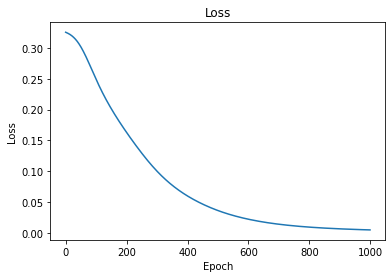

In [10]:
#plot the loss
plt.plot(epoch_loss)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [11]:
#now we need to test the model
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_class = y_pred.round()
    acc = y_pred_class.eq(Y_test_tensor).sum() / float(Y_test_tensor.shape[0])
    print(acc)

#now we need to save the model
torch.save(model.state_dict(), "fx_embed_model.pt")

tensor(8.8333)


In [12]:
print(type(y_pred_class))
print(y_pred_class.shape)


<class 'torch.Tensor'>
torch.Size([24, 10])


[[1 0 0 0 0 0 1 0 0 0]
 [0 2 0 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 1 0 0]
 [0 0 0 2 0 0 0 0 0 0]
 [2 0 0 0 1 0 0 0 0 0]
 [1 0 0 2 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 0 1 0 0 1 1 0 0]
 [0 0 0 1 0 0 0 0 0 1]
 [1 1 0 0 0 0 0 0 0 0]]
['Chris Lord Alge' 'Manny Marroquin' 'Serban Ghenea' 'Tom Elmhirst'
 'Bob Clearmountain' 'Jaycen Joshua' 'Josh Gudwin' 'Tony Maserati'
 'Mark Spike Stent' 'Dave Pensado']


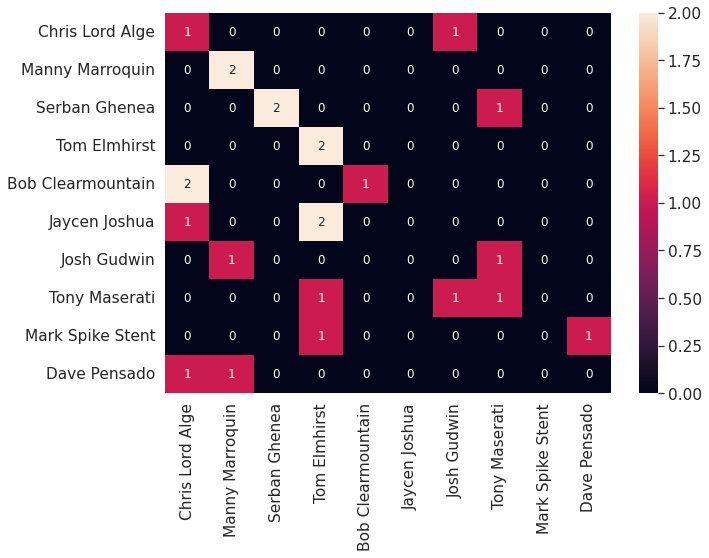

In [13]:
#plot a confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

confusion_matrix = confusion_matrix(Y_test_tensor.numpy().argmax(axis=1), y_pred_class.numpy().argmax(axis=1))
print(confusion_matrix)
#convert the labels to strings
labels = eng_dataset["eng"].unique()
print(labels)
#plot the confusion matrix
df_cm = pd.DataFrame(confusion_matrix, labels, labels)
#df_cm = pd.DataFrame(confusion_matrix, range(10), range(10))
plt.figure(figsize=(10,7))
sns.set(font_scale=1.4) # for label size
sns.heatmap(df_cm, annot=True, annot_kws={"size": 12}) # font size
plt.show()



In [14]:
#compute class-wise accuracy, precision, recall and f1 score
from sklearn.metrics import classification_report
print(classification_report(Y_test_tensor.numpy().argmax(axis=1), y_pred_class.numpy().argmax(axis=1), target_names=labels))


                   precision    recall  f1-score   support

  Chris Lord Alge       0.20      0.50      0.29         2
  Manny Marroquin       0.50      1.00      0.67         2
    Serban Ghenea       1.00      0.67      0.80         3
     Tom Elmhirst       0.33      1.00      0.50         2
Bob Clearmountain       1.00      0.33      0.50         3
    Jaycen Joshua       0.00      0.00      0.00         3
      Josh Gudwin       0.00      0.00      0.00         2
    Tony Maserati       0.33      0.33      0.33         3
 Mark Spike Stent       0.00      0.00      0.00         2
     Dave Pensado       0.00      0.00      0.00         2

         accuracy                           0.38        24
        macro avg       0.34      0.38      0.31        24
     weighted avg       0.38      0.38      0.33        24



/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/homes/ssv02/.conda/envs/seprem/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
